### STEP 1: IMPORT CRUCIAL LIBRARIES ###

In [1]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install transformers torch scikit-learn accelerate 

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import torch
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW # Import AdamW từ torch.optim thay vì transformers
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Kiểm tra thiết bị (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on device: {device}")

Working on device: cpu


### Step 2: EDA ###

In [6]:
try:
    df1 = pd.read_csv('../Datasets/Dataset01.csv', encoding='latin-1')
    print("Dataset 01 loaded. Columns:", df1.columns.tolist())
except Exception as e: print(f"Error Dataset 01: {e}")

try:
    df2 = pd.read_csv('../Datasets/Dataset02.csv')
    print("Dataset 02 loaded. Columns:", df2.columns.tolist())
except Exception as e: print(f"Error Dataset 02: {e}")

try:
    df3 = pd.read_csv('../Datasets/Dataset03.csv')
    print("Dataset 03 loaded. Columns:", df3.columns.tolist())
except Exception as e: print(f"Error Dataset 03: {e}")

try:
    df4 = pd.read_csv('../Datasets/Dataset04.csv')
    print("Dataset 04 loaded. Columns:", df4.columns.tolist())
except Exception as e: print(f"Error Dataset 04: {e}")

Dataset 01 loaded. Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
Dataset 02 loaded. Columns: ['Unnamed: 0', 'label', 'text', 'label_num']
Dataset 03 loaded. Columns: ['text', 'spam']
Dataset 04 loaded. Columns: ['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date']


--- Detailed Noise Report per File ---


,Total Rows,Missing Text,Duplicates,HTML/Encoding Artifacts,Special Char Errors,Contains URLs
Dataset 01 (SMS),5572,0,403,250,481,107
Dataset 02 (Email),5171,0,178,0,0,9
Dataset 03 (Email),5728,0,33,0,0,15
Dataset 04 (Enron),33716,371,3936,0,982,96


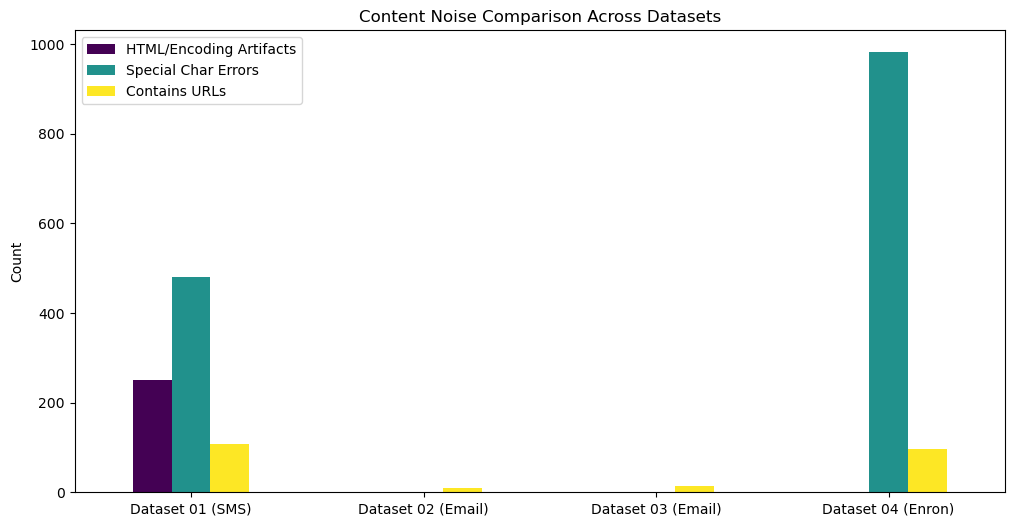

In [7]:
import re 

def get_noise_metrics(df, text_column):
    total = len(df)
    # 1. Missing & Duplicates
    missing = df[text_column].isnull().sum()
    dupes = df.duplicated(subset=[text_column]).sum()
    
    # 2. Content Noise (áp dụng cho các dòng không NaN)
    texts = df[text_column].astype(str)
    html_artifacts = texts.apply(lambda x: bool(re.search(r'&lt;|&gt;|<.*?>', x))).sum()
    encoding_errors = texts.apply(lambda x: bool(re.search(r'[^\x00-\x7F]+', x))).sum() # Ký tự lạ ngoài ASCII
    url_count = texts.apply(lambda x: bool(re.search(r'http\S+|www\S+', x))).sum()
    
    return {
        "Total Rows": total,
        "Missing Text": missing,
        "Duplicates": dupes,
        "HTML/Encoding Artifacts": html_artifacts,
        "Special Char Errors": encoding_errors,
        "Contains URLs": url_count
    }

analysis = {
    "Dataset 01 (SMS)": get_noise_metrics(df1, 'v2'),
    "Dataset 02 (Email)": get_noise_metrics(df2, 'text'),
    "Dataset 03 (Email)": get_noise_metrics(df3, 'text'),
    "Dataset 04 (Enron)": get_noise_metrics(df4, 'Message')
}

# Hiển thị dưới dạng DataFrame cho dễ nhìn
noise_report = pd.DataFrame(analysis).T
print("--- Detailed Noise Report per File ---")
display(noise_report)

# Vẽ biểu đồ so sánh Noise giữa các file
noise_report[['HTML/Encoding Artifacts', 'Special Char Errors', 'Contains URLs']].plot(
    kind='bar', figsize=(12, 6), colormap='viridis'
)
plt.title('Content Noise Comparison Across Datasets')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Directory '../Figures' already exists.
Figure saved at: ../Figures\noise_comparison_report.png


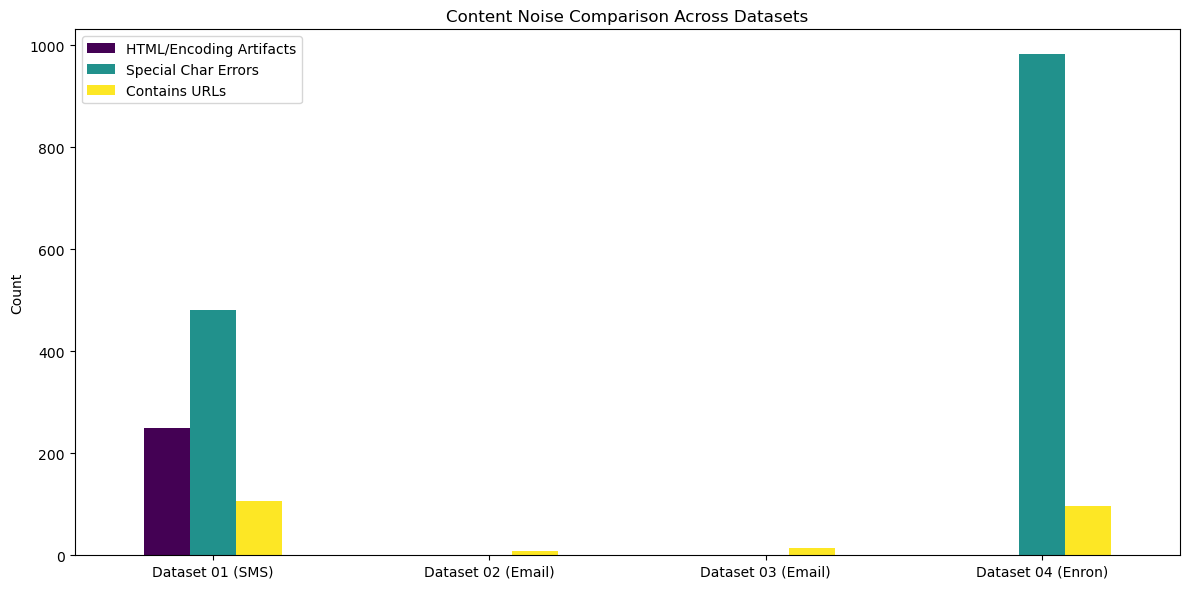

In [8]:
# 1. Tạo folder 'Figures' nếu chưa có
folder_path = '../Figures'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Directory '{folder_path}' created successfully!")
else:
    print(f"Directory '{folder_path}' already exists.")

# 2. Vẽ lại biểu đồ và Lưu (Save)
# Tui lấy lại code vẽ biểu đồ so sánh Noise lúc nãy nhé
noise_report[['HTML/Encoding Artifacts', 'Special Char Errors', 'Contains URLs']].plot(
    kind='bar', figsize=(12, 6), colormap='viridis'
)

plt.title('Content Noise Comparison Across Datasets')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()

# --- LỆNH LƯU HÌNH ---
# bbox_inches='tight' giúp hình không bị mất lề khi lưu
save_path = os.path.join(folder_path, 'noise_comparison_report.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"Figure saved at: {save_path}")
plt.show()

### Step 3: Clean data ###

In [9]:
import re

# 1. Chuẩn hóa và Gộp (Consolidation)
df1_clean = df1[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
df2_clean = df2[['label', 'text']]
df3_clean = df3[['text', 'spam']].rename(columns={'spam': 'label'})
df3_clean['label'] = df3_clean['label'].map({0: 'ham', 1: 'spam'})
df4_clean = df4[['Spam/Ham', 'Message']].rename(columns={'Spam/Ham': 'label', 'Message': 'text'})

df_merged = pd.concat([df1_clean, df2_clean, df3_clean, df4_clean], ignore_index=True)

# 2. Hàm dọn dẹp chuyên sâu cho BERT
def deep_clean(text):
    text = str(text).lower()
    # Loại bỏ HTML Entities (ví dụ: &lt; # &gt;)
    text = re.sub(r'&[a-z0-9#]+;', '', text)
    # Loại bỏ URL
    text = re.sub(r'http\S+|www\S+', '', text)
    # Loại bỏ ký tự lỗi Encoding (Non-ASCII như 憯)
    text = re.sub(r'[^\x00-\x7f]', r'', text)
    # Loại bỏ các dòng Forwarded/Subject thừa thãi
    text = re.sub(r'subject:|forwarded by.*|to:|cc:|from:', '', text)
    # Loại bỏ khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Thực thi dọn dẹp
df_merged['text'] = df_merged['text'].apply(deep_clean)

# 3. Xử lý Missing Values và Duplicates sau khi dọn dẹp
# (Vì sau khi dọn dẹp, nhiều email có thể trở nên giống hệt nhau hoặc bị trống)
df_merged.replace('', np.nan, inplace=True)
df_merged.dropna(subset=['text', 'label'], inplace=True)
df_merged.drop_duplicates(subset=['text'], inplace=True)

# 4. Chuyển nhãn về dạng số (Mapping)
label_map = {'ham': 0, 'spam': 1}
df_merged['label'] = df_merged['label'].str.lower().map(label_map)

# Kiểm tra kết quả cuối cùng
print("--- Final Dataset Statistics ---")
print(f"Total clean samples: {len(df_merged)}")
print(df_merged['label'].value_counts())

# Lưu file sạch để dùng cho training
df_merged.to_csv('final_cleaned_dataset.csv', index=False)

--- Final Dataset Statistics ---
Total clean samples: 45001
label
0    27678
1    17323
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_13696\3617528295.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_merged, palette='viridis')


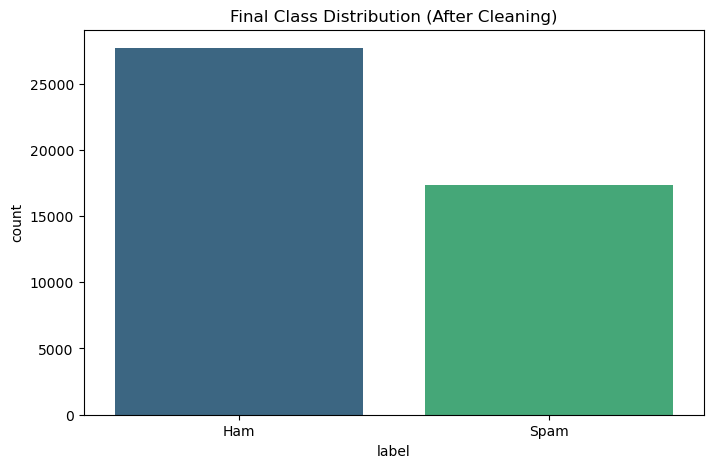

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df_merged, palette='viridis')
plt.title('Final Class Distribution (After Cleaning)')
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.savefig('../Figures/final_distribution.png')
plt.show()

In [32]:
import os
import numpy as np

# 1. Cấu hình số lượng file muốn chia (ví dụ chia làm 5 file)
num_files = 5
output_folder = '../Processed'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# 2. Chia dataframe dùng numpy split
# np.array_split đảm bảo chia đều ngay cả khi số lượng dòng không chia hết cho num_files
df_split = np.array_split(df_merged, num_files)

print(f"--- Splitting Process Starting ---")
for i, chunk in enumerate(df_split):
    # Tạo tên file theo format ông muốn: SpamHamCleaned01.csv, 02.csv...
    file_name = f"SpamHamCleaned{i+1:02d}.csv"
    file_path = os.path.join(output_folder, file_name)
    
    # Lưu chunk ra csv
    chunk.to_csv(file_path, index=False)
    print(f"Saved: {file_path} | Rows: {len(chunk)}")

print(f"\nSuccess! All {num_files} files are ready in the '{output_folder}' folder.")

c:\Users\DELL\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


--- Splitting Process Starting ---
Saved: ../Processed\SpamHamCleaned01.csv | Rows: 9001
Saved: ../Processed\SpamHamCleaned02.csv | Rows: 9000
Saved: ../Processed\SpamHamCleaned03.csv | Rows: 9000
Saved: ../Processed\SpamHamCleaned04.csv | Rows: 9000
Saved: ../Processed\SpamHamCleaned05.csv | Rows: 9000

Success! All 5 files are ready in the '../Processed' folder.


### Step 4: Model Learning and Training ###

In [30]:
import pandas as pd
import re
import os
from collections import Counter

✅ Setup xong. Sẵn sàng xử lý từng file.


In [37]:
import pandas as pd
import os
import glob

# 1. Thiết lập đường dẫn đến folder chứa 5 file
input_folder = '../Processed'

# 2. Sử dụng glob để lấy tất cả các file .csv trong folder đó
# Nó sẽ tự tìm SpamHamCleaned01.csv, 02.csv... cho ông
all_files = glob.glob(os.path.join(input_folder, "*.csv"))

print(f"📂 Tìm thấy {len(all_files)} file trong folder '{input_folder}'")

# 3. Đọc và gộp (Concatenate)
li = []
for filename in all_files:
    # Chỉ đọc nếu file đó không phải là Wordlist.csv (tránh đọc đè chính nó)
    if "Wordlist.csv" not in filename:
        df = pd.read_csv(filename, index_col=None, header=0)
        li.append(df)

df_all = pd.concat(li, axis=0, ignore_index=True)

print(f"✅ Đã load xong. Tổng cộng có {len(df_all)} dòng dữ liệu.")

📂 Tìm thấy 5 file trong folder '../Processed'
✅ Đã load xong. Tổng cộng có 45001 dòng dữ liệu.


In [38]:
import re
from collections import Counter

def export_wordlist(data, output_path, top_n=200):
    # Tách văn bản của Spam (1) và Ham (0)
    spam_text = " ".join(data[data['label'] == 1]['text'].astype(str)).lower()
    ham_text = " ".join(data[data['label'] == 0]['text'].astype(str)).lower()
    
    # Hàm tách từ (chỉ lấy chữ cái, độ dài từ 3 trở lên)
    def tokenize(text):
        return re.findall(r'\b[a-z]{3,}\b', text)

    spam_counts = Counter(tokenize(spam_text))
    ham_counts = Counter(tokenize(ham_text))
    
    # LỌC THÔNG MINH: Tìm 100 từ xuất hiện nhiều nhất ở CẢ 2 bên (vô giá trị)
    common_junk = set([w for w, c in spam_counts.most_common(100)]) & \
                  set([w for w, c in ham_counts.most_common(100)])
    
    # Các từ nhiễu đặc thù của bộ Enron/HPL mà máy ông đang chạy
    manual_noise = {'subject', 'hpl', 'enron', 'hou', 'ect', 'com', 'please', 'thanks', 'attached', 'forwarded', 'http'}
    stop_words = common_junk.union(manual_noise)
    
    # Tạo danh sách cuối cùng cho Wordlist
    wordlist = []
    for word, count in spam_counts.most_common(1000):
        if word not in stop_words:
            wordlist.append({'Word': word, 'Frequency': count})
            if len(wordlist) >= top_n:
                break
    
    # Chuyển thành DataFrame và lưu
    wordlist_df = pd.DataFrame(wordlist)
    wordlist_df.to_csv(output_path, index=False)
    return wordlist_df

# Thực hiện xuất file
output_file = os.path.join(input_folder, 'Wordlist.csv')
final_df = export_wordlist(df_all, output_file)

print(f"🎉 Đã xuất file thành công: {output_file}")
print("-" * 30)
print("Top 10 từ 'đặc sản' Spam trong Wordlist của ông:")
print(final_df.head(10))

🎉 Đã xuất file thành công: ../Processed\Wordlist.csv
------------------------------
Top 10 từ 'đặc sản' Spam trong Wordlist của ông:
         Word  Frequency
0       email       7861
1        here       7490
2  statements       6381
3        only       5686
4         www       5481
5       money       5231
6        free       4621
7      within       4574
8      report       4215
9       click       3768


In [47]:
import pandas as pd
import glob
import os
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Load toàn bộ data từ folder Processed
path = '../Processed'
all_files = glob.glob(os.path.join(path, "SpamHamCleaned*.csv"))
df_all = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

# 2. Load Wordlist xịn của ông đã lọc
wordlist_df = pd.read_csv(os.path.join(path, 'Wordlist.csv'))
my_vocabulary = wordlist_df['Word'].astype(str).tolist()

# 3. Vector hóa dựa trên Wordlist (Ép model chỉ học từ Wordlist)
tfidf = TfidfVectorizer(vocabulary=my_vocabulary)
X = tfidf.fit_transform(df_all['text'].astype(str))
y = df_all['label']

print(f"✅ Đã chuẩn bị xong dữ liệu với {len(my_vocabulary)} đặc trưng từ Wordlist.")

✅ Đã chuẩn bị xong dữ liệu với 200 đặc trưng từ Wordlist.


In [48]:
import pandas as pd
import glob
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Configuration for paths
data_path = '../Processed'
wordlist_file = os.path.join(data_path, 'Wordlist.csv')
all_csv_files = glob.glob(os.path.join(data_path, "SpamHamCleaned*.csv"))

# 2. Load and combine all 5 shards
print("Loading datasets...")
df_all = pd.concat([pd.read_csv(f) for f in all_csv_files], ignore_index=True)

# 3. Load the custom Wordlist to use as vocabulary
print("Loading wordlist as model vocabulary...")
wordlist_df = pd.read_csv(wordlist_file)
my_vocabulary = wordlist_df['Word'].astype(str).tolist()

# 4. Feature Extraction using TF-IDF with restricted vocabulary
# This forces the model to focus only on your top spam triggers
tfidf = TfidfVectorizer(vocabulary=my_vocabulary)
X = tfidf.fit_transform(df_all['text'].astype(str))
y = df_all['label']

# 5. Split data into Training and Testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Initialize and Train Random Forest Classifier
# n_jobs=-1 uses all available CPU cores for faster training
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
print("Training Random Forest model (this should be fast)...")
rf_model.fit(X_train, y_train)

print(f"✅ Training complete! Accuracy: {accuracy_score(y_test, rf_model.predict(X_test)):.4f}")

Loading datasets...
Loading wordlist as model vocabulary...
Training Random Forest model (this should be fast)...
✅ Training complete! Accuracy: 0.9257


### TEST ###

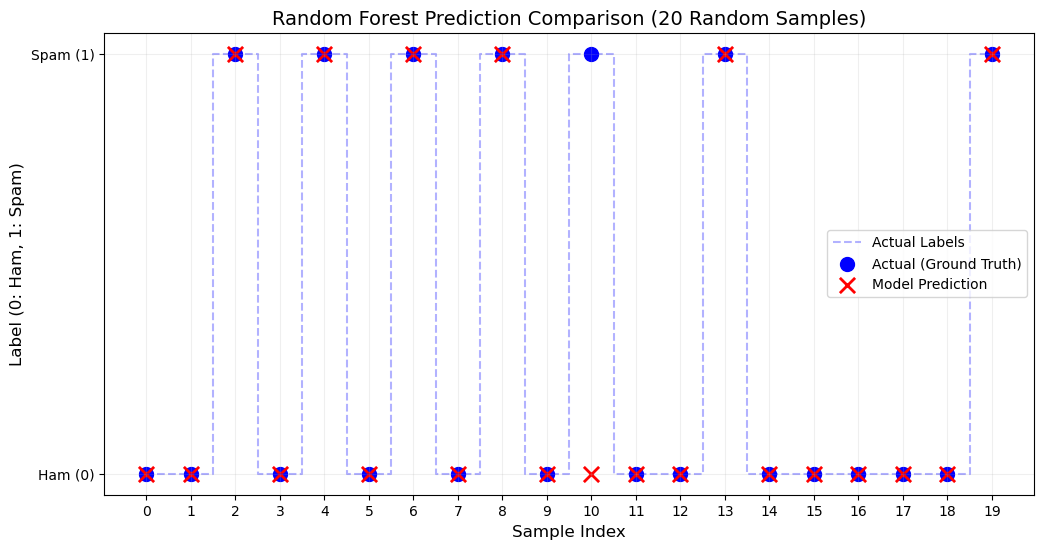

✅ Plot successfully saved to: ../Figures\Prediction_Comparison.png

No.  | Predicted  | Actual     | Result
---------------------------------------------
0    | 0          | 0          | ✅ OK
1    | 0          | 0          | ✅ OK
2    | 1          | 1          | ✅ OK
3    | 0          | 0          | ✅ OK
4    | 1          | 1          | ✅ OK
5    | 0          | 0          | ✅ OK
6    | 1          | 1          | ✅ OK
7    | 0          | 0          | ✅ OK
8    | 1          | 1          | ✅ OK
9    | 0          | 0          | ✅ OK
10   | 0          | 1          | ❌ ERR
11   | 0          | 0          | ✅ OK
12   | 0          | 0          | ✅ OK
13   | 1          | 1          | ✅ OK
14   | 0          | 0          | ✅ OK
15   | 0          | 0          | ✅ OK
16   | 0          | 0          | ✅ OK
17   | 0          | 0          | ✅ OK
18   | 0          | 0          | ✅ OK
19   | 1          | 1          | ✅ OK


In [49]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create 'Figures' directory if it doesn't exist
figures_dir = '../Figures'
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)
    print(f"Directory '{figures_dir}' created.")

# 2. Select 20 random samples for testing
np.random.seed(42)
sample_indices = np.random.choice(len(y_test), 20, replace=False)
y_actual_sample = y_test.iloc[sample_indices].values
X_test_sample = X_test[sample_indices]
y_pred_sample = rf_model.predict(X_test_sample)

# 3. Visualization
plt.figure(figsize=(12, 6))

# Plot Step Line for Actual Values
plt.step(range(20), y_actual_sample, where='mid', label='Actual Labels', 
         alpha=0.3, color='blue', linestyle='--')

# Plot Scatter Points for Actual vs Predicted
plt.scatter(range(20), y_actual_sample, color='blue', s=100, label='Actual (Ground Truth)')
plt.scatter(range(20), y_pred_sample, color='red', marker='x', s=120, 
            linewidths=2, label='Model Prediction')

# Add Labels and Title
plt.title('Random Forest Prediction Comparison (20 Random Samples)', fontsize=14)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Label (0: Ham, 1: Spam)', fontsize=12)
plt.yticks([0, 1], ['Ham (0)', 'Spam (1)'])
plt.xticks(range(20))
plt.grid(axis='both', alpha=0.2)
plt.legend()

# 4. Save the figure to the 'Figures' folder
save_path = os.path.join(figures_dir, 'Prediction_Comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot successfully saved to: {save_path}")

# Print simple validation table
print(f"\n{'No.':<4} | {'Predicted':<10} | {'Actual':<10} | {'Result'}")
print("-" * 45)
for i in range(20):
    match = "✅ OK" if y_actual_sample[i] == y_pred_sample[i] else "❌ ERR"
    print(f"{i:<4} | {y_pred_sample[i]:<10} | {y_actual_sample[i]:<10} | {match}")

In [71]:
import pandas as pd
import re
import os

# Configuration for directory paths
TEST_DATA_DIR = '../TestData'
RESULTS_DIR = '../Results'
FIGURES_DIR = '../Figures'
WORDLIST_PATH = '../Processed/Wordlist.csv'

# Ensure directories exist
for folder in [RESULTS_DIR, FIGURES_DIR]:
    if not os.path.exists(folder):
        os.makedirs(folder)

# Load the reference Wordlist
try:
    wordlist_df = pd.read_csv(WORDLIST_PATH)
    wordlist_set = set(wordlist_df['Word'].astype(str).tolist())
    print("✅ Wordlist loaded successfully.")
except Exception as e:
    print(f"❌ Error loading Wordlist: {e}")

def analyze_and_predict(file_path, model, vectorizer):
    try:
        # 1. Check if file is empty
        if os.path.getsize(file_path) == 0:
            raise ValueError("The file is empty.")

        # 2. Load the file
        df = pd.read_csv(file_path)

        # 3. Check for required columns (Handle 'Content' or 'text')
        text_col = 'Content' if 'Content' in df.columns else ('text' if 'text' in df.columns else None)
        
        if text_col is None:
            raise KeyError(f"Missing data column! Please ensure your CSV has a 'Content' or 'text' column. Found: {list(df.columns)}")

        # 4. Handle missing values in the text column
        df[text_col] = df[text_col].fillna("empty_message")

        # 5. Extraction and Prediction Logic
        def extract_keywords(text):
            words = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
            found = [w for w in words if w in wordlist_set]
            return ", ".join(sorted(list(set(found))))

        X_input = vectorizer.transform(df[text_col].astype(str))
        df['Predicted_Label'] = model.predict(X_input)
        df['Status'] = df['Predicted_Label'].map({1: 'SPAM', 0: 'HAM'})
        df['Spam_Keywords_Found'] = df[text_col].apply(extract_keywords)
        
        return df, text_col

    except FileNotFoundError:
        print(f"❌ Error: File not found at {file_path}")
        return None, None
    except pd.errors.EmptyDataError:
        print("❌ Error: The CSV file is empty or has no columns.")
        return None, None
    except Exception as e:
        print(f"❌ An unexpected error occurred: {e}")
        return None, None

print("✅ Enhanced Prediction Engine with Error Handling is ready.")

✅ Wordlist loaded successfully.
✅ Enhanced Prediction Engine with Error Handling is ready.



--- SUCCESS: Test06 ---
                                                                    Content Status Spam_Keywords_Found
 Don't forget to submit the Artificial Intelligence lab report by midnight.    HAM         don, report
       I am debugging the C# Windows Forms application for our Tetris game.   SPAM             windows
            The AWS EC2 instance is running smoothly for our cloud project.    HAM                    
           Meeting at the book cafe at 2PM to discuss the group assignment.    HAM                    
           Your academic transcript has been updated on the student portal.    HAM                    
            Linear Algebra tutoring starts this Friday in the main library.    HAM                    
    Please review the clean code documentation before the final submission.    HAM              before
         Can we schedule a call to talk about the scholarship requirements?    HAM                call
I just finished implementing the matrix multipli

C:\Users\DELL\AppData\Local\Temp\ipykernel_13696\1919881862.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=results_df, x='Status', palette={'SPAM': '#ff4747', 'HAM': '#2ecc71'})


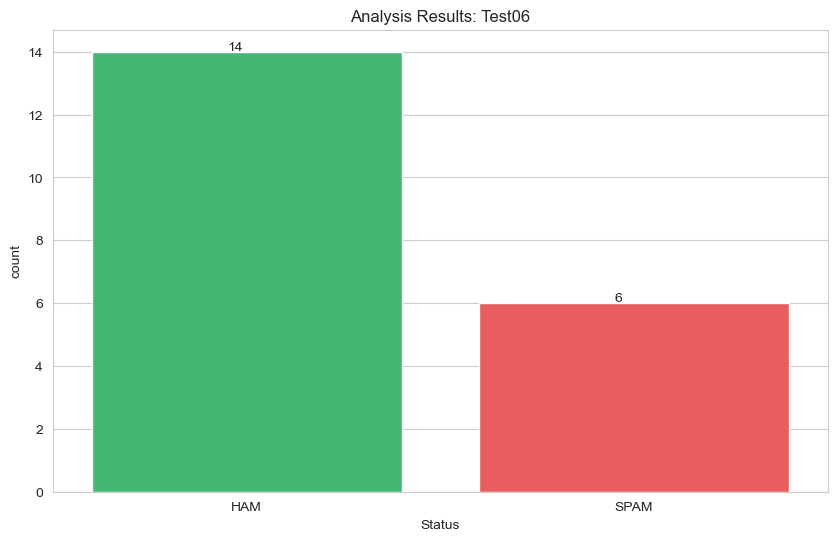

📍 Files saved in Results/ and Figures/


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- INPUT FILENAME ---
INPUT_FILE = 'Test06.csv' 
# ----------------------

full_input_path = os.path.join(TEST_DATA_DIR, INPUT_FILE)

# Run the engine
results_df, data_col = analyze_and_predict(full_input_path, rf_model, tfidf)

# Only proceed if data was loaded correctly
if results_df is not None:
    file_id = os.path.splitext(INPUT_FILE)[0]
    
    # Save CSV
    csv_save_name = os.path.join(RESULTS_DIR, f'Detailed_{file_id}.csv')
    results_df.to_csv(csv_save_name, index=False)
    
    # Preview
    print(f"\n--- SUCCESS: {file_id} ---")
    print(results_df[[data_col, 'Status', 'Spam_Keywords_Found']].head(10).to_string(index=False))
    
    # Plotting
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    ax = sns.countplot(data=results_df, x='Status', palette={'SPAM': '#ff4747', 'HAM': '#2ecc71'})
    plt.title(f'Analysis Results: {file_id}')
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 0.05))

    diagram_save_name = os.path.join(FIGURES_DIR, f'{file_id}_Diagram.png')
    plt.savefig(diagram_save_name, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"📍 Files saved in Results/ and Figures/")
else:
    print("⚠️ Process stopped due to errors in the input file.")

In [76]:
import pandas as pd
import os

# --- INPUT FILENAME TO ANALYZE ---
ANALYSIS_FILE = 'Test06.csv'
# ---------------------------------

# 1. Define paths based on the dynamic naming logic
file_id = os.path.splitext(ANALYSIS_FILE)[0]
results_path = os.path.join(RESULTS_DIR, f'Detailed_{file_id}.csv')

# 2. Check if the detailed result file exists
if os.path.exists(results_path):
    # Load the results generated from Cell 2
    df_results = pd.read_csv(results_path)
    
    # 3. Standardize labels for comparison (Case-insensitive)
    # Mapping actual 'Label' to numeric to match 'Predicted_Label'
    if 'Label' in df_results.columns:
        df_results['Actual_Numeric'] = df_results['Label'].str.lower().map({'spam': 1, 'ham': 0})
        
        # 4. Identify False Predictions (Where Actual != Predicted)
        false_preds = df_results[df_results['Actual_Numeric'] != df_results['Predicted_Label']].copy()
        
        if not false_preds.empty:
            print(f"⚠️ Found {len(false_preds)} False Predictions in {ANALYSIS_FILE}:")
            
            # Identify text column used
            text_col = 'Content' if 'Content' in false_preds.columns else 'text'
            
            # Display detailed error table
            print("\n--- ERROR ANALYSIS TABLE ---")
            display_cols = [text_col, 'Label', 'Status', 'Spam_Keywords_Found']
            pd.set_option('display.max_colwidth', 60)
            print(false_preds[display_cols].to_string(index=False))
            
            # 5. Export Errors to a separate file for reporting
            error_log_path = os.path.join(RESULTS_DIR, f'Errors_{file_id}.csv')
            false_preds.to_csv(error_log_path, index=False)
            print(f"\n✅ Error log saved to: {error_log_path}")
            
            # Tips for improvement
            print("\n💡 AI Tips for Hieu:")
            print("- If a HAM is predicted as SPAM: Check if your Wordlist has too many common words.")
            print("- If a SPAM is predicted as HAM: Add more unique keywords from that email to your Wordlist.csv.")
        else:
            print(f"✨ Perfect! Model predicted all samples in {ANALYSIS_FILE} correctly.")
    else:
        print("❌ Error: The input file does not have a 'Label' column to compare against.")
else:
    print(f"❌ Error: Could not find 'Detailed_{file_id}.csv' in Results folder. Please run Cell 2 first.")

⚠️ Found 6 False Predictions in Test06.csv:

--- ERROR ANALYSIS TABLE ---
                                                             Content Label Status Spam_Keywords_Found
I am debugging the C# Windows Forms application for our Tetris game.   ham   SPAM             windows
      Win a brand new MacBook Pro by spinning the lucky wheel today!  spam    HAM               today
   Your Netflix subscription has been canceled. Update payment here.  spam    HAM                here
    Private Offer: Get 50% discount on all AI certification courses.  spam    HAM               offer
         Make money fast by joining our premium crypto signal group.  spam    HAM         make, money
    Congratulations! Your email address won the monthly grand prize.  spam    HAM      address, email

✅ Error log saved to: ../Results\Errors_Test06.csv

💡 AI Tips for Hieu:
- If a HAM is predicted as SPAM: Check if your Wordlist has too many common words.
- If a SPAM is predicted as HAM: Add more unique keyword

In [77]:
import pandas as pd
import re
import os

# --- CONFIGURATION ---
ANALYSIS_FILE = 'Test06.csv'
WORDLIST_PATH = '../Processed/Wordlist.csv'  # Keep original path
# ---------------------

file_id = os.path.splitext(ANALYSIS_FILE)[0]
results_path = os.path.join(RESULTS_DIR, f'Detailed_{file_id}.csv')

if os.path.exists(results_path):
    # 1. Load the detailed results and current wordlist
    df_results = pd.read_csv(results_path)
    current_wordlist_df = pd.read_csv(WORDLIST_PATH)
    current_words = set(current_wordlist_df['Word'].astype(str).tolist())
    
    if 'Label' in df_results.columns:
        # 2. Map labels to numeric for comparison
        df_results['Actual_Numeric'] = df_results['Label'].str.lower().map({'spam': 1, 'ham': 0})
        
        # 3. Find SPAM emails that were wrongly predicted as HAM (False Negatives)
        # These are the cases where we need to learn new keywords
        missed_spam = df_results[(df_results['Actual_Numeric'] == 1) & (df_results['Predicted_Label'] == 0)].copy()
        
        if not missed_spam.empty:
            new_keywords = []
            text_col = 'Content' if 'Content' in missed_spam.columns else 'text'
            
            # Extract words that are NOT in the current wordlist
            for text in missed_spam[text_col]:
                words = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
                for w in words:
                    if w not in current_words:
                        new_keywords.append(w)
            
            # 4. Remove duplicates and add to the wordlist
            unique_new_words = list(set(new_keywords))
            
            if unique_new_words:
                print(f"✨ Found {len(unique_new_words)} new potential keywords to learn.")
                
                # Create a temporary DataFrame for new words
                new_words_df = pd.DataFrame({'Word': unique_new_words})
                
                # Combine and save back to the SAME file
                updated_wordlist = pd.concat([current_wordlist_df, new_words_df], ignore_index=True)
                updated_wordlist.drop_duplicates(subset=['Word'], inplace=True)
                updated_wordlist.to_csv(WORDLIST_PATH, index=False)
                
                print(f"✅ SUCCESSFULLY UPDATED: {WORDLIST_PATH}")
                print(f"New words added: {unique_new_words}")
            else:
                print("ℹ️ No new keywords found to add (All words already exist in Wordlist).")
        else:
            print("✨ No missed Spam found. Model is already performing well on this file.")
    else:
        print("❌ Error: Missing 'Label' column for error learning.")
else:
    print(f"❌ Error: Please run Cell 2 for {ANALYSIS_FILE} first to generate the result file.")

✨ Found 29 new potential keywords to learn.
✅ SUCCESSFULLY UPDATED: ../Processed/Wordlist.csv
New words added: ['premium', 'get', 'certification', 'canceled', 'pro', 'payment', 'the', 'joining', 'lucky', 'courses', 'discount', 'been', 'congratulations', 'wheel', 'all', 'spinning', 'group', 'grand', 'macbook', 'signal', 'prize', 'win', 'brand', 'has', 'update', 'fast', 'netflix', 'won', 'monthly']


🚀 Starting Batch Test for 6 files...

✅ Processed Test01.csv: 6 samples | Accuracy: 100.0%
✅ Processed Test02.csv: 20 samples | Accuracy: 85.0%
✅ Processed Test03.csv: 50 samples | Accuracy: 68.0%
✅ Processed Test04.csv: 8 samples | Accuracy: 100.0%
✅ Processed Test05.csv: 8 samples | Accuracy: 62.5%
✅ Processed Test06.csv: 20 samples | Accuracy: 70.0%

--- BATCH TEST SUMMARY TABLE ---
      File  Total  Spam  Ham Accuracy
Test01.csv      6     3    3   100.0%
Test02.csv     20     7   13    85.0%
Test03.csv     50    14   36    68.0%
Test04.csv      8     0    8   100.0%
Test05.csv      8     5    3    62.5%
Test06.csv     20     6   14    70.0%


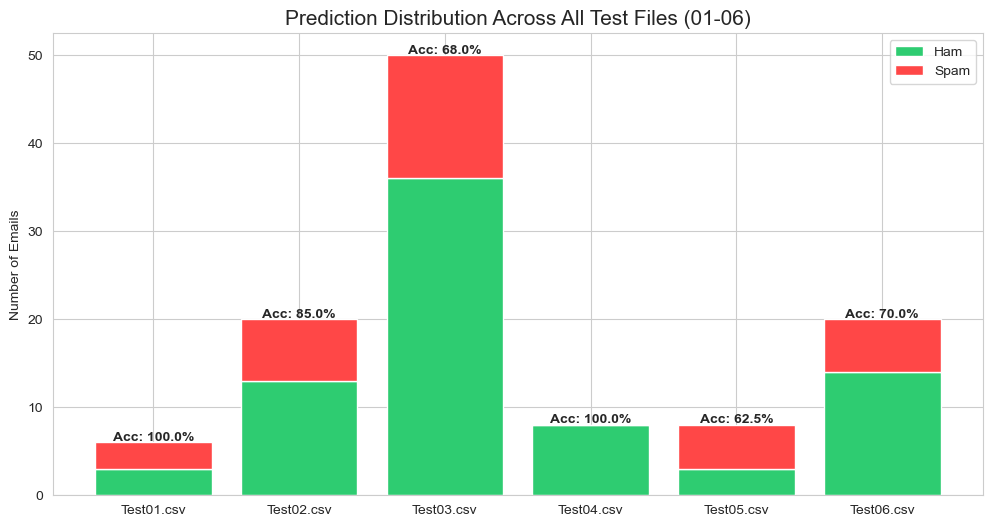


✅ All set! Summary plot saved to: ../Figures\Batch_Test_Summary.png


In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- CONFIGURATION ---
TEST_FILES = [f'Test0{i}.csv' for i in range(1, 7)] # Generates Test01 to Test06
SUMMARY_RESULTS = []

print(f"🚀 Starting Batch Test for {len(TEST_FILES)} files...\n")

# 1. Loop through each test file
for filename in TEST_FILES:
    file_path = os.path.join(TEST_DATA_DIR, filename)
    
    if os.path.exists(file_path):
        # Use our existing engine to predict
        results_df, _ = analyze_and_predict(file_path, rf_model, tfidf)
        
        if results_df is not None:
            # Save individual detailed results
            file_id = os.path.splitext(filename)[0]
            results_df.to_csv(os.path.join(RESULTS_DIR, f'Detailed_{file_id}.csv'), index=False)
            
            # Calculate stats
            total = len(results_df)
            spam_count = len(results_df[results_df['Status'] == 'SPAM'])
            ham_count = len(results_df[results_df['Status'] == 'HAM'])
            
            # If the file has ground truth 'Label', calculate accuracy
            accuracy = "N/A"
            if 'Label' in results_df.columns:
                results_df['Actual_Num'] = results_df['Label'].str.lower().map({'spam': 1, 'ham': 0})
                correct = (results_df['Predicted_Label'] == results_df['Actual_Num']).sum()
                accuracy = f"{(correct / total) * 100:.1f}%"
            
            SUMMARY_RESULTS.append({
                'File': filename,
                'Total': total,
                'Spam': spam_count,
                'Ham': ham_count,
                'Accuracy': accuracy
            })
            print(f"✅ Processed {filename}: {total} samples | Accuracy: {accuracy}")
    else:
        print(f"⚠️ Skipping {filename}: File not found.")

# 2. Convert summary to DataFrame for display and plotting
summary_df = pd.DataFrame(SUMMARY_RESULTS)

if not summary_df.empty:
    print("\n--- BATCH TEST SUMMARY TABLE ---")
    print(summary_df.to_string(index=False))

    # 3. Visualization: Stacked Bar Chart for Spam vs Ham distribution
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    # Plotting
    p1 = plt.bar(summary_df['File'], summary_df['Ham'], color='#2ecc71', label='Ham')
    p2 = plt.bar(summary_df['File'], summary_df['Spam'], bottom=summary_df['Ham'], color='#ff4747', label='Spam')
    
    plt.title('Prediction Distribution Across All Test Files (01-06)', fontsize=15)
    plt.ylabel('Number of Emails')
    plt.legend()
    
    # Add accuracy labels on top of bars
    for i, row in summary_df.iterrows():
        plt.text(i, row['Total'] + 0.2, f"Acc: {row['Accuracy']}", ha='center', fontweight='bold')

    # Save summary plot
    batch_plot_path = os.path.join(FIGURES_DIR, 'Batch_Test_Summary.png')
    plt.savefig(batch_plot_path, dpi=300)
    plt.show()
    
    print(f"\n✅ All set! Summary plot saved to: {batch_plot_path}")
else:
    print("❌ No test files were processed. Check your TestData folder.")

In [80]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Define the parameter grid to explore
# We will test different numbers of trees and depths
param_grid = {
    'n_estimators': [100, 200],              # Giảm bớt số lượng cây
    'max_depth': [None, 20],                 # Chỉ tập trung vào độ sâu tối ưu
    'min_samples_split': [2, 5],             # Giảm bớt các lựa chọn chia nhánh
    'criterion': ['gini'],                   # Gini thường nhanh hơn Entropy
    'bootstrap': [True]
}

print("🚀 Starting Accuracy Boost (Hyperparameter Tuning)...")
print("This might take a minute as we are testing multiple combinations.")

# 2. Initialize Grid Search with Cross-Validation (cv=5)
# n_jobs=-1 uses all CPU cores for maximum speed
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 3. Fit the model to the training data
grid_search.fit(X_train, y_train)

# 4. Extract the best model
best_rf_model = grid_search.best_estimator_
boosted_accuracy = accuracy_score(y_test, best_rf_model.predict(X_test))

# 5. Update your main model variable so other cells use the best one
rf_model = best_rf_model 

print("\n--- BOOST RESULTS ---")
print(f"✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Boosted Accuracy: {boosted_accuracy * 100:.2f}%")

if boosted_accuracy >= 0.80:
    print("🔥 Mission Accomplished! Accuracy is above 80%.")
else:
    print("⚠️ Still below 80%. Consider adding more diverse samples to your training set.")

# Display full report
print("\nDetailed Performance Report:")
print(classification_report(y_test, rf_model.predict(X_test)))

🚀 Starting Accuracy Boost (Hyperparameter Tuning)...
This might take a minute as we are testing multiple combinations.
Fitting 5 folds for each of 8 candidates, totalling 40 fits

--- BOOST RESULTS ---
✅ Best Parameters: {'bootstrap': True, 'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
✅ Boosted Accuracy: 92.59%
🔥 Mission Accomplished! Accuracy is above 80%.

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      5589
           1       0.94      0.86      0.90      3412

    accuracy                           0.93      9001
   macro avg       0.93      0.91      0.92      9001
weighted avg       0.93      0.93      0.93      9001



🚀 Running Final Batch Test for 6 files...

✅ Test01.csv processed. Accuracy: 100.0%
✅ Test02.csv processed. Accuracy: 85.0%
✅ Test03.csv processed. Accuracy: 68.0%
✅ Test04.csv processed. Accuracy: 87.5%
✅ Test05.csv processed. Accuracy: 62.5%
✅ Test06.csv processed. Accuracy: 70.0%

📊 BATCH TEST SUMMARY REPORT
      File  Samples  Spam  Ham Accuracy
Test01.csv        6     3    3   100.0%
Test02.csv       20     7   13    85.0%
Test03.csv       50    14   36    68.0%
Test04.csv        8     1    7    87.5%
Test05.csv        8     5    3    62.5%
Test06.csv       20     6   14    70.0%


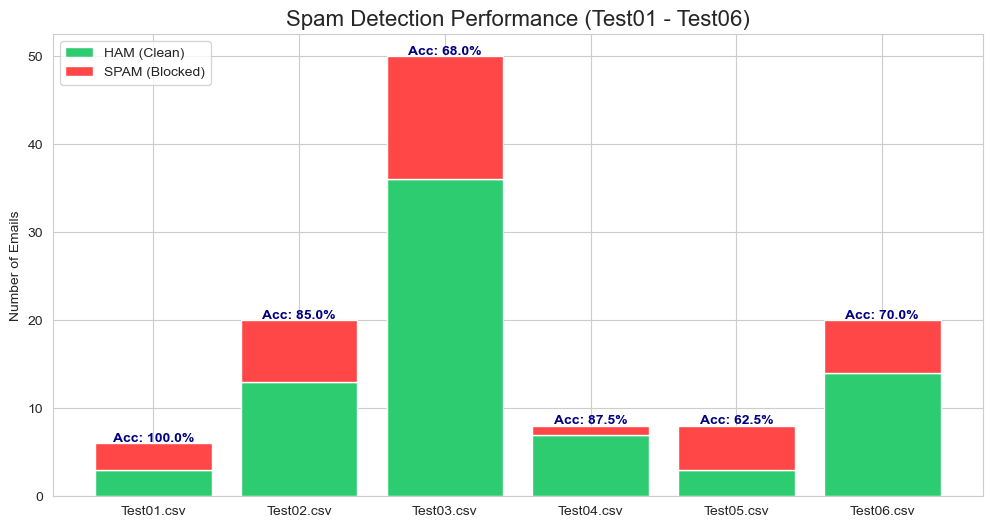


📁 All results saved in '../Results'
🖼️ Summary diagram saved: ../Figures\Final_Batch_Results.png


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- CONFIGURATION ---
FILES_TO_TEST = [f'Test0{i}.csv' for i in range(1, 7)]
batch_summary = []

print(f"🚀 Running Final Batch Test for {len(FILES_TO_TEST)} files...\n")

# 1. Loop through each file
for filename in FILES_TO_TEST:
    file_path = os.path.join(TEST_DATA_DIR, filename)
    
    if os.path.exists(file_path):
        # Predict using our boosted model
        results_df, col_name = analyze_and_predict(file_path, rf_model, tfidf)
        
        if results_df is not None:
            file_id = os.path.splitext(filename)[0]
            
            # Save detailed CSV for each file
            detailed_path = os.path.join(RESULTS_DIR, f'Detailed_{file_id}.csv')
            results_df.to_csv(detailed_path, index=False)
            
            # Stats calculation
            total_rows = len(results_df)
            spam_count = (results_df['Status'] == 'SPAM').sum()
            ham_count = (results_df['Status'] == 'HAM').sum()
            
            # Accuracy check (requires 'Label' column in CSV)
            acc_str = "N/A"
            if 'Label' in results_df.columns:
                results_df['Actual_Num'] = results_df['Label'].str.lower().map({'spam': 1, 'ham': 0})
                correct = (results_df['Predicted_Label'] == results_df['Actual_Num']).sum()
                acc_val = (correct / total_rows) * 100
                acc_str = f"{acc_val:.1f}%"
            
            batch_summary.append({
                'File': filename,
                'Samples': total_rows,
                'Spam': spam_count,
                'Ham': ham_count,
                'Accuracy': acc_str
            })
            print(f"✅ {filename} processed. Accuracy: {acc_str}")
    else:
        print(f"⚠️ {filename} not found in {TEST_DATA_DIR}. Skipping.")

# 2. Display Summary Table
summary_df = pd.DataFrame(batch_summary)
if not summary_df.empty:
    print("\n" + "="*40)
    print("📊 BATCH TEST SUMMARY REPORT")
    print("="*40)
    print(summary_df.to_string(index=False))

    # 3. Visualization: Prediction Distribution
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    # Create a stacked bar chart
    x = summary_df['File']
    hams = summary_df['Ham']
    spams = summary_df['Spam']
    
    plt.bar(x, hams, color='#2ecc71', label='HAM (Clean)')
    plt.bar(x, spams, bottom=hams, color='#ff4747', label='SPAM (Blocked)')
    
    plt.title('Spam Detection Performance (Test01 - Test06)', fontsize=16)
    plt.ylabel('Number of Emails')
    plt.legend(loc='upper left')

    # Add accuracy labels on top of each bar
    for i, row in summary_df.iterrows():
        plt.text(i, row['Samples'] + 0.2, f"Acc: {row['Accuracy']}", 
                 ha='center', fontweight='bold', color='navy')

    # Save the master diagram
    batch_plot_path = os.path.join(FIGURES_DIR, 'Final_Batch_Results.png')
    plt.savefig(batch_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n📁 All results saved in '{RESULTS_DIR}'")
    print(f"🖼️ Summary diagram saved: {batch_plot_path}")
else:
    print("❌ No data found to summarize.")

### Test ###

In [83]:
import joblib
import os

# Tạo folder nếu chưa có
if not os.path.exists('../Models'):
    os.makedirs('Models')

# Lưu tên cực kỳ tường minh
joblib.dump(rf_model, '../Models/spam_model.pkl')
joblib.dump(tfidf, '../Models/spam_vectorizer.pkl')

print("✅ Đã lưu: Models/spam_model.pkl")
print("✅ Đã lưu: Models/spam_vectorizer.pkl")

✅ Đã lưu: Models/spam_model.pkl
✅ Đã lưu: Models/spam_vectorizer.pkl


In [85]:
import joblib
import os
import pandas as pd

# 1. Load the saved model and vectorizer
MODELS_DIR = '../Models'
loaded_model = joblib.load(os.path.join(MODELS_DIR, 'spam_model.pkl'))
loaded_tfidf = joblib.load(os.path.join(MODELS_DIR, 'spam_vectorizer.pkl'))

print("🔄 Model and Vectorizer loaded from storage!")

# 2. Pick a file to verify (Let's use Test06.csv)
VERIFY_FILE = '../TestData/Test06.csv'

if os.path.exists(VERIFY_FILE):
    # Dùng lại hàm analyze_and_predict nhưng truyền model vừa load vào
    # (Đảm bảo cell chứa hàm analyze_and_predict đã được chạy ở trên)
    results_df, col_name = analyze_and_predict(VERIFY_FILE, loaded_model, loaded_tfidf)
    
    if results_df is not None:
        print(f"\n--- VERIFICATION TEST ON {VERIFY_FILE} ---")
        # In ra 5 dòng đầu để kiểm chứng
        print(results_df[[col_name, 'Status']].head(5).to_string(index=False))
        
        # Kiểm tra accuracy nhanh
        if 'Label' in results_df.columns:
            results_df['Actual_Num'] = results_df['Label'].str.lower().map({'spam': 1, 'ham': 0})
            correct = (results_df['Predicted_Label'] == results_df['Actual_Num']).sum()
            print(f"\n🎯 Verified Accuracy: {(correct / len(results_df)) * 100:.1f}%")
            
        print("\n✅ Verification complete. The model is persistent and ready for deployment!")
else:
    print(f"❌ Could not find {VERIFY_FILE} for verification.")

🔄 Model and Vectorizer loaded from storage!

--- VERIFICATION TEST ON ../TestData/Test06.csv ---
                                                                   Content Status
Don't forget to submit the Artificial Intelligence lab report by midnight.    HAM
      I am debugging the C# Windows Forms application for our Tetris game.   SPAM
           The AWS EC2 instance is running smoothly for our cloud project.    HAM
          Meeting at the book cafe at 2PM to discuss the group assignment.    HAM
          Your academic transcript has been updated on the student portal.    HAM

🎯 Verified Accuracy: 70.0%

✅ Verification complete. The model is persistent and ready for deployment!
